In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
# load data 
data =pd.read_excel(r"C:\Users\Lenovo\Desktop\used_cars_data_cleaned.xlsx")

In [5]:
data

,Name,Location,Year,Car_Age,Fuel_Type,Transmission,Owner_Type,Kilometers_Driven,Mileage_Value,Engine_CC,Power_BHP,Seats,New_Price_Lakh,Price_Lakh
0,Maruti Wagon R LXI CNG,Mumbai,2010,14,CNG,Manual,First,72000,26.60,998,58.16,5,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,9,Diesel,Manual,First,41000,19.67,1582,126.20,5,NaN,12.50
2,Honda Jazz V,Chennai,2011,13,Petrol,Manual,First,46000,18.20,1199,88.70,5,8.61,4.50
3,Maruti Ertiga VDI,Chennai,2012,12,Diesel,Manual,First,87000,20.77,1248,88.76,7,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,11,Diesel,Automatic,Second,40670,15.20,1968,140.80,5,NaN,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,Maruti Swift VDI,Delhi,2014,10,Diesel,Manual,First,27365,28.40,1248,74.00,5,7.88,4.75
6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,9,Diesel,Manual,First,100000,24.40,1120,71.00,5,NaN,4.00
6016,Mahindra Xylo D4 BSIV,Jaipur,2012,12,Diesel,Manual,Second,55000,14.00,2498,112.00,8,NaN,2.90
6017,Maruti Wagon R VXI,Kolkata,2013,11,Petrol,Manual,First,46000,18.90,998,67.10,5,NaN,2.65


In [8]:
data['model'] = data['Name'].str.split(expand=True)[1]

In [10]:
data.drop('Name', axis=1, inplace=True)
data.head(2)

,Location,Year,Car_Age,Fuel_Type,Transmission,Owner_Type,Kilometers_Driven,Mileage_Value,Engine_CC,Power_BHP,Seats,New_Price_Lakh,Price_Lakh,brand,model
0,Mumbai,2010,14,CNG,Manual,First,72000,26.60,998,58.16,5,NaN,1.75,Maruti,Wagon
1,Pune,2015,9,Diesel,Manual,First,41000,19.67,1582,126.20,5,NaN,12.50,Hyundai,Creta


In [11]:
# encoding 
# Assigning a unique numbers to a categorical vlaue in a colu 
data.Location.unique()

<StringArray>
[    'Mumbai',       'Pune',    'Chennai', 'Coimbatore',  'Hyderabad',
     'Jaipur',      'Kochi',    'Kolkata',      'Delhi',  'Bangalore',
  'Ahmedabad']
Length: 11, dtype: str

In [12]:
# encode Transmission manuall
data.Transmission.unique()


<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [13]:
enc_trans={'Manual' :1 , 'Automatic':2}

In [16]:
data['Transmission'].map(enc_trans)

0       1
1       1
2       1
3       1
4       2
       ..
6014    1
6015    1
6016    1
6017    1
6018    1
Name: Transmission, Length: 6019, dtype: int64

In [17]:
data['Transmission_encoded']= data['Transmission'].map(enc_trans)
data.head(2)

,Location,Year,Car_Age,Fuel_Type,Transmission,Owner_Type,Kilometers_Driven,Mileage_Value,Engine_CC,Power_BHP,Seats,New_Price_Lakh,Price_Lakh,brand,model,Transmission_encoded
0,Mumbai,2010,14,CNG,Manual,First,72000,26.60,998,58.16,5,NaN,1.75,Maruti,Wagon,1
1,Pune,2015,9,Diesel,Manual,First,41000,19.67,1582,126.20,5,NaN,12.50,Hyundai,Creta,1


In [22]:
# Encode Location using dictionary 
locs=sorted(list(data['Location'].unique()))
#locs = locs.sort()
print(locs, end='')

['Ahmedabad', 'Bangalore', 'Chennai', 'Coimbatore', 'Delhi', 'Hyderabad', 'Jaipur', 'Kochi', 'Kolkata', 'Mumbai', 'Pune']

In [24]:
r = len(locs)
indx= list(range(r))
print(indx)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [27]:
enc_locs = dict(zip(locs,indx))
print(enc_locs, end=' ')

{'Ahmedabad': 0, 'Bangalore': 1, 'Chennai': 2, 'Coimbatore': 3, 'Delhi': 4, 'Hyderabad': 5, 'Jaipur': 6, 'Kochi': 7, 'Kolkata': 8, 'Mumbai': 9, 'Pune': 10} 

In [30]:
data['Location encoded'] = data['Location'].map(enc_locs)

In [31]:
data

,Location,Year,Car_Age,Fuel_Type,Transmission,Owner_Type,Kilometers_Driven,Mileage_Value,Engine_CC,Power_BHP,Seats,New_Price_Lakh,Price_Lakh,brand,model,Transmission_encoded,Location encoded
0,Mumbai,2010,14,CNG,Manual,First,72000,26.60,998,58.16,5,NaN,1.75,Maruti,Wagon,1,9
1,Pune,2015,9,Diesel,Manual,First,41000,19.67,1582,126.20,5,NaN,12.50,Hyundai,Creta,1,10
2,Chennai,2011,13,Petrol,Manual,First,46000,18.20,1199,88.70,5,8.61,4.50,Honda,Jazz,1,2
3,Chennai,2012,12,Diesel,Manual,First,87000,20.77,1248,88.76,7,NaN,6.00,Maruti,Ertiga,1,2
4,Coimbatore,2013,11,Diesel,Automatic,Second,40670,15.20,1968,140.80,5,NaN,17.74,Audi,A4,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,Delhi,2014,10,Diesel,Manual,First,27365,28.40,1248,74.00,5,7.88,4.75,Maruti,Swift,1,4
6015,Jaipur,2015,9,Diesel,Manual,First,100000,24.40,1120,71.00,5,NaN,4.00,Hyundai,Xcent,1,6
6016,Jaipur,2012,12,Diesel,Manual,Second,55000,14.00,2498,112.00,8,NaN,2.90,Mahindra,Xylo,1,6
6017,Kolkata,2013,11,Petrol,Manual,First,46000,18.90,998,67.10,5,NaN,2.65,Maruti,Wagon,1,8


# Encode the Values using labelEncoder 

In [33]:
from sklearn.preprocessing import LabelEncoder 

In [34]:
le = LabelEncoder()

In [1]:
# Basic Stats 

In [36]:
print(list(data['model'].unique()), end=' ')

['Wagon', 'Creta', 'Jazz', 'Ertiga', 'A4', 'EON', 'Micra', 'Innova', 'Vento', 'Indica', 'Ciaz', 'City', 'Swift', 'Rover', 'Pajero', 'Amaze', 'Duster', 'New', '3', 'S', 'A6', 'i20', 'Alto', 'WRV', 'Corolla', 'Ssangyong', 'Vitara', 'KUV', 'M-Class', 'Polo', 'Nano', 'Elantra', 'Xcent', 'Thar', 'Grand', 'KWID', 'i10', 'X-Trail', 'Zen', 'Figo', 'C-Class', 'Cayenne', 'XUV500', 'Terrano', 'Brio', 'Fiesta', 'Santro', 'Zest', 'Ritz', '5', 'Fortuner', 'Ecosport', 'Verna', 'GO', 'Omni', 'Etios', 'XF', 'Eeco', 'Civic', 'V40', 'B', 'Scorpio', 'CR-V', 'SLC', '1', 'Beat', 'Rapid', 'RS5', 'Superb', 'X5', 'GLC', 'Countryman', 'Optra', 'Lodgy', 'E-Class', 'Baleno', 'Laura', 'NuvoSport', 'Fabia', 'Indigo', 'Q3', 'Octavia', 'A8', 'Verito', 'Cooper', 'Santa', 'X1', 'Accent', 'Tucson', 'GLE', 'A-Star', 'Grande', 'X3', 'EcoSport', 'Q7', 'Jetta', 'GLA', 'Celerio', 'Sumo', 'Accord', '6', 'Manza', 'Spark', 'Clubman', 'Teana', '800', 'BRV', 'XE', 'Xenon', 'A3', 'GL-Class', 'BR-V', 'S80', 'Captur', 'Enjoy', 'Bole

In [37]:
le.fit_transform(data['model'])

array([189,  53,  99, ..., 204, 189,  26], shape=(6019,))

In [39]:
data['model_encoded'] = le.fit_transform(data['model'])
data.head(2)

,Location,Year,Car_Age,Fuel_Type,Transmission,Owner_Type,Kilometers_Driven,Mileage_Value,Engine_CC,Power_BHP,Seats,New_Price_Lakh,Price_Lakh,brand,model,Transmission_encoded,Location encoded,model_encoded
0,Mumbai,2010,14,CNG,Manual,First,72000,26.60,998,58.16,5,NaN,1.75,Maruti,Wagon,1,9,189
1,Pune,2015,9,Diesel,Manual,First,41000,19.67,1582,126.20,5,NaN,12.50,Hyundai,Creta,1,10,53


In [42]:
data[['model', 'model_encoded']]

,model,model_encoded
0,Wagon,189
1,Creta,53
2,Jazz,99
3,Ertiga,69
4,A4,10
...,...,...
6014,Swift,169
6015,Xcent,202
6016,Xylo,204
6017,Wagon,189


# Scaling 


In [ ]:
# converting data in to a small  manageable size without loosting its original property 
# Maps (Saler 147...)
# ML aglorith M
# Plann 

In [43]:
data.head(2)

,Location,Year,Car_Age,Fuel_Type,Transmission,Owner_Type,Kilometers_Driven,Mileage_Value,Engine_CC,Power_BHP,Seats,New_Price_Lakh,Price_Lakh,brand,model,Transmission_encoded,Location encoded,model_encoded
0,Mumbai,2010,14,CNG,Manual,First,72000,26.60,998,58.16,5,NaN,1.75,Maruti,Wagon,1,9,189
1,Pune,2015,9,Diesel,Manual,First,41000,19.67,1582,126.20,5,NaN,12.50,Hyundai,Creta,1,10,53


In [ ]:
# MinMax Scaler  (min 0 max 1)
# Standard Scaler (scaleds such that the std is alwayz 0) 

<Axes: title={'center': 'Mileage and Enginer Distributon befroe Scaling'}, xlabel='Mileage_Value', ylabel='Engine_CC'>

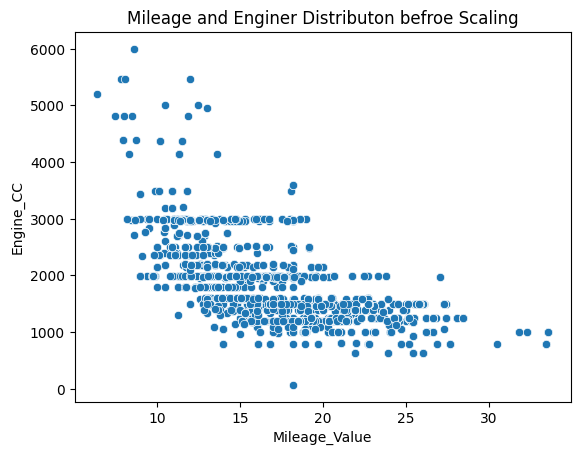

In [45]:
plt.title("Mileage and Enginer Distributon befroe Scaling")
sns.scatterplot(x='Mileage_Value', y='Engine_CC', data=data)

In [46]:
# Scaled with Min Max Scaler 
from  sklearn.preprocessing import MinMaxScaler

In [47]:
scaler= MinMaxScaler()

In [56]:
df=data[['Mileage_Value', 'Engine_CC','Power_BHP']]
df.head(2)

,Mileage_Value,Engine_CC,Power_BHP
0,26.60,998,58.16
1,19.67,1582,126.20


In [57]:
# Scaled the 'df' with min max scael
df_minmax = scaler.fit_transform(df)
df_minmax

array([[0.74428887, 0.15626055, 0.04556866],
       [0.4889462 , 0.25480931, 0.17497147],
       [0.43478261, 0.19017887, 0.10365158],
       ...,
       [0.28002948, 0.40938238, 0.14796501],
       [0.4605748 , 0.15626055, 0.06257132],
       [0.70154753, 0.14579818, 0.04450361]], shape=(6019, 3))

In [58]:
# convert array 'df_minmax' in to dataframe 
df_minmax = pd.DataFrame(df_minmax, columns = df.columns)
df_minmax.head(2)

,Mileage_Value,Engine_CC,Power_BHP
0,0.744289,0.156261,0.045569
1,0.488946,0.254809,0.174971


<Axes: title={'center': 'Data After Scaling'}, xlabel='Mileage_Value', ylabel='Engine_CC'>

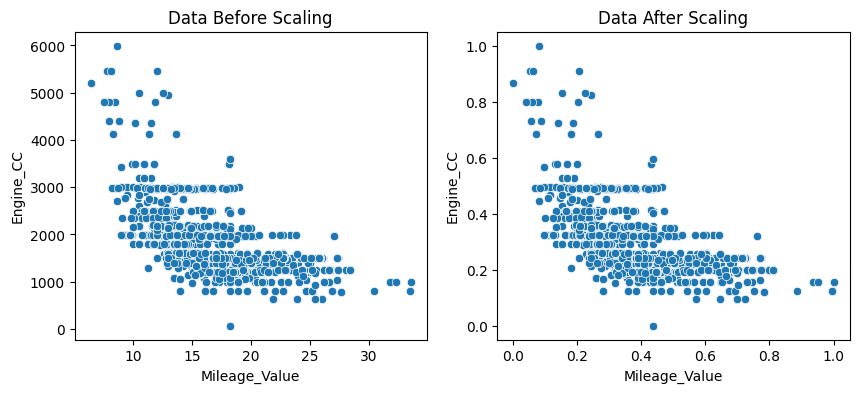

In [65]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].set_title("Data Before Scaling")
axes[1].set_title("Data After Scaling")
sns.scatterplot(x='Mileage_Value', y='Engine_CC', data=data, ax=axes[0])
sns.scatterplot(x='Mileage_Value',  y='Engine_CC', data=df_minmax, ax=axes[1])

<Axes: title={'center': 'Data After Scaling'}>

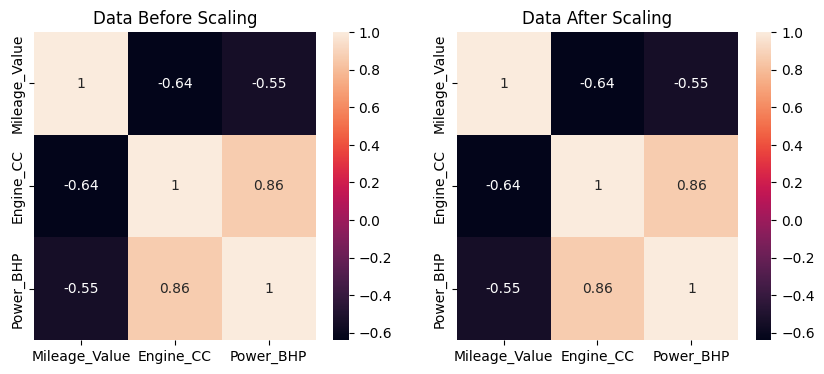

In [68]:
# Plot in Co-Relation 
fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].set_title("Data Before Scaling")
axes[1].set_title("Data After Scaling")
sns.heatmap(df.corr(),annot=True, ax=axes[0])
sns.heatmap(df.corr(),annot=True, ax=axes[1])

In [69]:
# Standard Scaler 
from sklearn.preprocessing import StandardScaler 

In [70]:
ss_scaler = StandardScaler()

In [72]:
ss_scaled = ss_scaler.fit_transform(df)
ss_scaled

array([[ 1.98983228, -1.03823236, -1.02710742],
       [ 0.32027583, -0.06422639,  0.24993698],
       [-0.03387251, -0.70300086, -0.45390142],
       ...,
       [-1.0457249 ,  1.46349531, -0.01658316],
       [ 0.13476956, -1.03823236, -0.85931235],
       [ 1.71036829, -1.14163711, -1.03761808]], shape=(6019, 3))

In [73]:
df_ss_scaled = pd.DataFrame(ss_scaled, columns = df.columns)
df_ss_scaled

,Mileage_Value,Engine_CC,Power_BHP
0,1.989832,-1.038232,-1.027107
1,0.320276,-0.064226,0.249937
2,-0.033873,-0.703001,-0.453901
3,0.585285,-0.621278,-0.452775
4,-0.756624,0.579552,0.523965
...,...,...,...
6014,2.423483,-0.621278,-0.729806
6015,1.459814,-0.834759,-0.786113
6016,-1.045725,1.463495,-0.016583
6017,0.134770,-1.038232,-0.859312


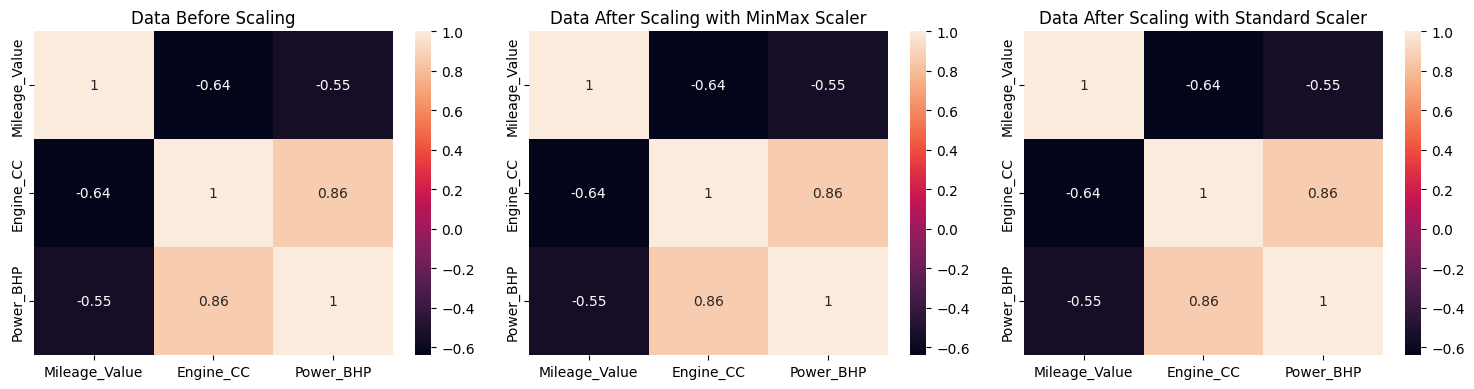

In [77]:
# Show the realtion in heatmap 
# Plot in Co-Relation 
fig, axes = plt.subplots(1,3,figsize=(15,4))
axes[0].set_title("Data Before Scaling")
axes[1].set_title("Data After Scaling with MinMax Scaler")
axes[2].set_title("Data After Scaling with Standard Scaler")
sns.heatmap(df.corr(),annot=True, ax=axes[0])
sns.heatmap(df_minmax.corr(),annot=True, ax=axes[1])
sns.heatmap(df_ss_scaled.corr(),annot=True, ax=axes[2])
plt.tight_layout()

In [ ]:
Measures of central tendency (mean, median, mode).
Measures of dispersion (variance, standard deviation).
Probability basics for data science.
Distribution concepts

In [ ]:
# Mean () average 
# Median () Central value after arranging in an order 
# Mode Most frequent valye

In [78]:
# Most frequent mileage vlaue 
data['Mileage_Value'].mode()

0    17.0
Name: Mileage_Value, dtype: float64

In [80]:
# Median  
data['Mileage_Value'].median()

np.float64(18.2)

In [81]:
# Mean  Value 
data['Mileage_Value'].mean()

np.float64(18.340598105997675)

In [83]:
# Range min - ma 
ma = data['Mileage_Value'].max()
print(f"Maximum Mileage: {ma}")

Maximum Mileage: 33.54


In [84]:
mi = data['Mileage_Value'].min()
print(f"Minimum Mileage : {mi}")

Minimum Mileage : 6.4


In [85]:
# Range (max - min) 
rng = ma - mi
print(f"Range of Mileage : {rng}")

Range of Mileage : 27.14


In [86]:
# Variance 
va = data['Mileage_Value'].var()
print(f"Variance of Mileage: {va}")

Variance of Mileage: 17.232028887806315


In [87]:
# Standard Devitaton 
sd = data['Mileage_Value'].std()
print(f"Standard Deviation: {sd}")

Standard Deviation: 4.1511479000158875


In [88]:
# quantile 
q1  =data['Mileage_Value'].quantile(0.25)  
print(f"First Quartile:{q1}")

First Quartile:15.4


In [89]:
# Get 90 percentiles of data 
p90 = data['Mileage_Value'].quantile(0.9)
print(f"90 Percentils of Data: {p90}")

90 Percentils of Data: 24.0


In [90]:
# Randomly pickking a car  what will  be probaility of gett a car of hyundai 
datasample(n=1)

,Location,Year,Car_Age,Fuel_Type,Transmission,Owner_Type,Kilometers_Driven,Mileage_Value,Engine_CC,Power_BHP,Seats,New_Price_Lakh,Price_Lakh,brand,model,Transmission_encoded,Location encoded,model_encoded
3706,Mumbai,2016,8,Diesel,Automatic,First,31000,21.76,1995,190.0,5,60.88,29.95,BMW,3,2,9,2


In [99]:
for x in range(10): 
    b = data['brand'].sample(n=1)
    print(f"Brand : {b}")

Brand : 5042    Audi
Name: brand, dtype: str
Brand : 3773    Hyundai
Name: brand, dtype: str
Brand : 3932    Toyota
Name: brand, dtype: str
Brand : 4704    Mercedes-Benz
Name: brand, dtype: str
Brand : 4642    Honda
Name: brand, dtype: str
Brand : 1646    Volkswagen
Name: brand, dtype: str
Brand : 2000    Mahindra
Name: brand, dtype: str
Brand : 5451    Hyundai
Name: brand, dtype: str
Brand : 2798    Mahindra
Name: brand, dtype: str
Brand : 3264    Toyota
Name: brand, dtype: str


In [100]:
1211/6019

0.20119621199534807

In [97]:
1/5

0.2

In [94]:
data.shape

(6019, 18)

In [95]:
1107 /6019 

0.18391759428476492

In [101]:
# Check the normalziation of data 
data['Mileage_Value'].skew()

np.float64(0.2131130955971552)

<Axes: xlabel='Mileage_Value', ylabel='Density'>

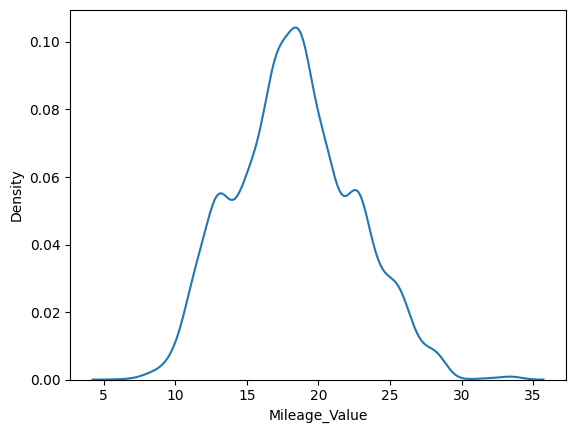

In [102]:
sns.kdeplot(x='Mileage_Value', data=data)

In [ ]:
Positve Far for 0 
0 
negative Far form z 

<Axes: xlabel='Power_BHP', ylabel='Density'>

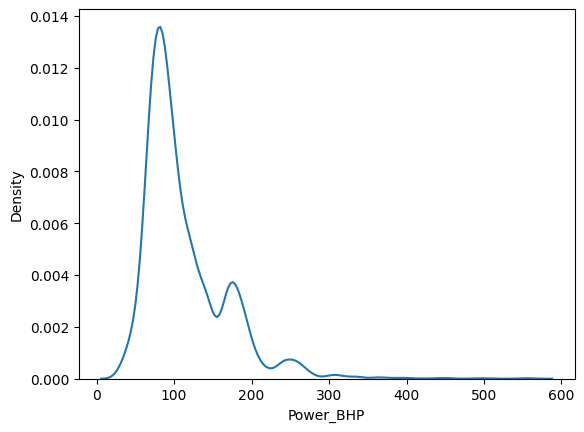

In [103]:
sns.kdeplot(x='Power_BHP', data=data)

In [104]:
data['Power_BHP'].skew()

np.float64(1.9541216786365463)